In [1]:
# from LadrunoGraphStyle import set_default_plot_params, main_colors
# set_default_plot_params()

In [2]:
from fem import (
    # Core
    Node, Material,
    # Sections
    Membrane,
    # Elements
    CST, LST, Quad4, Quad9,
    # Gmsh tools
    read_mesh, build_nodes, build_elements, build_load_vector,
    # Visualization — Gmsh
    add_element_data_view, add_node_data_view, compute_nodal_average, plot_gmsh_mesh,
    # Plotting — matplotlib
    plot_mesh, plot_field_2d, plot_deformed, plot_loads_2d ,
    # Units
    mm, cm, m, kgf, N, tf, kN, MPa, GPa, kg,
    # Parameters
    globalParameters,
)
# Standard libraries
import os
import numpy as np
np.set_printoptions(suppress=True, precision=6, linewidth=400)
import matplotlib.pyplot as plt
import gmsh
import math


  FEM -- Finite Element Method for Structural Analysis
  Based on the course by Prof. José Abell

  Version 0.1.0                        © 2026 All Rights Reserved

  Repository  :  https://github.com/ppalacios92/FEM
  Web Book    :  https://books.nmorabowen.com/books/fem

  Patricio Palacios B.    |    Nicolas Mora Bowen

  ********* (>'-')> Ladruño4ever  *********



In [ ]:
globalParameters['nDoF'] = 2
globalParameters['nDIM'] = 2

In [4]:
# General model parameters
L = 1000 
H = 1000  
B = 10
lc = 50
R = 200 
output_path = os.getcwd()
mesh_name = 'plate_with_hole'
output_file = os.path.join(output_path, mesh_name + '.msh')

if not os.path.exists(output_path):
    os.makedirs(output_path)

In [5]:
# Create a new GMSH model
gmsh.initialize()
gmsh.model.add(mesh_name)

# Create the corner points of the beam
p1 = gmsh.model.geo.addPoint(0, 0, 0, lc)
p2 = gmsh.model.geo.addPoint(L, 0, 0, lc)
p3 = gmsh.model.geo.addPoint(L, H, 0, lc)
p4 = gmsh.model.geo.addPoint(0, H, 0, lc)

# Define the outer rectangle lines
l1 = gmsh.model.geo.addLine(p1, p2)  # Base
l2 = gmsh.model.geo.addLine(p2, p3)  # Lateral derecho
l3 = gmsh.model.geo.addLine(p3, p4)  # Tope
l4 = gmsh.model.geo.addLine(p4, p1)  # Lateral izquierdo

# Create the outer curve loop
c1 = gmsh.model.geo.addCurveLoop([l1, l2, l3, l4])

# Create the circular hole in the center (4 puntos para que sea divisible por 2)
center_x = L / 2
center_y = H / 2
pc = gmsh.model.geo.addPoint(center_x, center_y, 0, lc)
p_right = gmsh.model.geo.addPoint(center_x + R, center_y, 0, lc)
p_top = gmsh.model.geo.addPoint(center_x, center_y + R, 0, lc)
p_left = gmsh.model.geo.addPoint(center_x - R, center_y, 0, lc)
p_bottom = gmsh.model.geo.addPoint(center_x, center_y - R, 0, lc)

# Create four quarter-circle arcs
arc1 = gmsh.model.geo.addCircleArc(p_right, pc, p_top)
arc2 = gmsh.model.geo.addCircleArc(p_top, pc, p_left)
arc3 = gmsh.model.geo.addCircleArc(p_left, pc, p_bottom)
arc4 = gmsh.model.geo.addCircleArc(p_bottom, pc, p_right)

# Create the hole curve loop
c2 = gmsh.model.geo.addCurveLoop([arc1, arc2, arc3, arc4])

# Create the surface with the hole
s1 = gmsh.model.geo.addPlaneSurface([c1, c2])

# Synchronize the model
gmsh.model.geo.synchronize()

# Create the physical groups
gmsh.model.addPhysicalGroup(2, [s1], 201)
gmsh.model.setPhysicalName(2, 201, "Beam")

# Apoyo en lado izquierdo (empotrado)
gmsh.model.addPhysicalGroup(1, [l4], 101) 
gmsh.model.setPhysicalName(1, 101, "Support1")

# Carga en el lado derecho
gmsh.model.addPhysicalGroup(1, [l2], 50) 
gmsh.model.setPhysicalName(1, 50, "Load")

# Synchronize the model
gmsh.model.geo.synchronize()

def all_quads():
    gmsh.model.geo.synchronize()
    gmsh.option.setNumber("Mesh.RecombineAll", 1)
    gmsh.option.setNumber("Mesh.Algorithm", 8)
    gmsh.option.setNumber("Mesh.RecombinationAlgorithm", 2)
    gmsh.option.setNumber("Mesh.Smoothing", 100)
    gmsh.option.setNumber("Mesh.ElementOrder", 1)

# all_quads()
# gmsh.option.setNumber("Mesh.ElementOrder", 1)


# Generate and save mesh
# gmsh.model.mesh.generate()
# gmsh.write(output_file)
# gmsh.fltk.run()
# gmsh.finalize()

In [6]:
# Generate the mesh
gmsh.model.mesh.generate()
# Save mesh to disk
gmsh.write(output_file)
# Open GMSH GUI
gmsh.fltk.run()
# Write mesh file again (redundant)
v = gmsh.write(output_file)
# Close GMSH instance
gmsh.finalize()

In [7]:
# Define material
Steel = Material(name='Steel',
             E=200000.00, #Mpa
             nu=0.30,
             rho=1.25*0)

# Define membrane section
SteelPlate = Membrane(name='SteelPlate',
                        thickness=B,
                        material=Steel)

# Map physical group id to section
section_dictionary = {201: SteelPlate}
                    
# Load magnitude
Pload = 10
load_dictionary = {
    50: {'value': 10, 'direction': 'x'}
}

# Boundary conditions
restrain_dictionary = {101: ['r', 'r']}

# Self-weight (not used)
self_weight = [0, 0]

In [8]:
# Read raw mesh data from gmsh file
mesh = read_mesh(output_file)

# Instantiate Node objects and apply boundary conditions
node_map, nodes, system_nDof = build_nodes(mesh, restrain_dictionary)

  MESH SUMMARY

  === NODES ===  (513 total — showing first 3)
     Tag              x              y              z
--------------------------------------------------------------------------------
       1         0.0000         0.0000         0.0000
       2      1000.0000         0.0000         0.0000
       3      1000.0000      1000.0000         0.0000
--------------------------------------------------------------------------------

  === PHYSICAL GROUPS ===  (3 total)
      ID    Dim   Name
--------------------------------------------------------------------------------
      50      1   'Load'
     101      1   'Support1'
     201      2   'Beam'
--------------------------------------------------------------------------------

  === ELEMENTS ===  (3 groups)
      ID    Dim     Type   Nodes/el   N elements   Name
--------------------------------------------------------------------------------
      50      1        1          2           20   'Load'
     101      1        1      

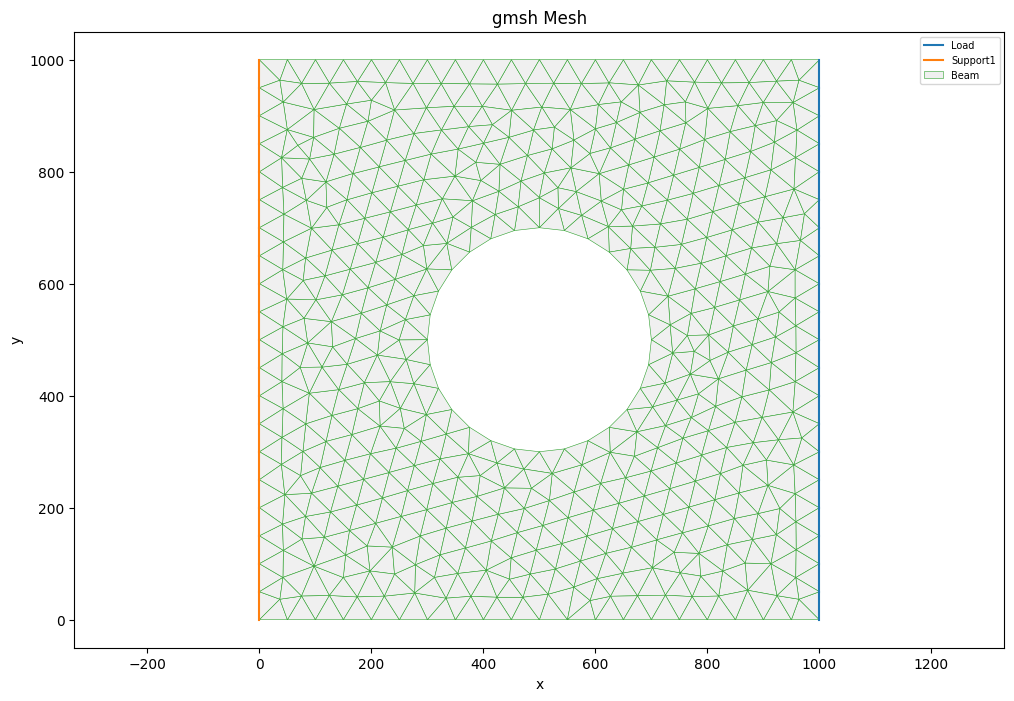

In [9]:
# %matplotlib widge
plot_gmsh_mesh(mesh,
               show_node_labels   = False,
               show_element_labels= False,
               show_node_points   = False,
            #    view_3d            = True,   elev= 45, azim= -45,
               figsize            = (12, 8))

In [10]:
# Map number of nodes per element to element class
element_map = {
    3: CST,         # 3-node triangles
    4: Quad4,       # 4-node quadrilaterals
    6: LST,         # 6-node triangles
    9: Quad9,       # 9-node quadrilaterals
}

# Instantiate FEM element objects from mesh connectivity
elements = build_elements(  mesh=mesh,
                            node_map=node_map,
                            section_dictionary=section_dictionary,
                            element_class_map=element_map )

In [11]:
# Build global nodal force vector from load dictionary
F_load = build_load_vector(mesh=mesh, 
                            node_map=node_map, 
                            load_dictionary=load_dictionary)

In [13]:
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

# Global stiffness matrix (sparse)
K = lil_matrix((system_nDof, system_nDof))
for element in elements:
    for i_local, i_global in enumerate(element.idx):
        for j_local, j_global in enumerate(element.idx):
            K[i_global, j_global] += element.kg[i_local, j_local]
K = K.tocsr()

# Force vector
F = np.zeros(system_nDof)
for node in nodes:
    F[node.idx] += node.nodalLoad
F += F_load

# DOF classification
dof_flags       = np.concatenate([node.restrain for node in nodes])
free_dofs       = np.where(dof_flags == 'f')[0]
restrained_dofs = np.where(dof_flags == 'r')[0]

# Remove load on restrained DOFs (they go to reactions directly)
F[restrained_dofs] = 0.0

# Partitioning
Kff = K[free_dofs[:, None], free_dofs]
Kfr = K[free_dofs[:, None], restrained_dofs]
Krf = K[restrained_dofs[:, None], free_dofs]
Krr = K[restrained_dofs[:, None], restrained_dofs]
Ff  = F[free_dofs]
Fr  = F[restrained_dofs]

# Solution
ur = np.zeros(len(restrained_dofs))
uf = spsolve(Kff, Ff - Kfr @ ur)

u = np.zeros(system_nDof)
u[free_dofs]       = uf
u[restrained_dofs] = ur

# Reactions
Rr      = Krf @ uf + Krr @ ur
R       = np.zeros(system_nDof)
R[restrained_dofs] = Rr

In [14]:
def get_node(node_map, u, tag=None, x=None, y=None):
    """
    Returns a node by tag or by closest position and prints its displacements.
    Provide either tag or (x, y), not both.
    """
    if tag is not None:
        node = node_map[tag]
    else:
        best_tag  = None
        best_dist = np.inf
        for t, n in node_map.items():
            dist = np.linalg.norm(n.coordinates - np.array([x, y]))
            if dist < best_dist:
                best_dist = dist
                best_tag  = t
        node = node_map[best_tag]

    d = u[node.idx]
    print(f"Node {node.name} at {node.coordinates}:  ux={d[0]:+.6f}  uy={d[1]:+.6f}")
    return node

In [15]:
# By tag
node = get_node(node_map, u , tag=3)
# By position
node = get_node(node_map, u, x=1000, y=500)

Node 3 at [1000. 1000.]:  ux=+0.005635  uy=+0.000304
Node 37 at [1000.  500.]:  ux=+0.008712  uy=-0.000004


In [17]:
# Reactions per node
for node in nodes:
    if any(r == 'r' for r in node.restrain):
        r = R[node.idx]
        print(f"Node {node.name}:  Rx={r[0]:+.6f}  Ry={r[1]:+.6f}")

# Equilibrium check
total_applied_x  = np.sum(F[0::2])
total_applied_y  = np.sum(F[1::2])
total_reaction_x = np.sum(R[0::2])
total_reaction_y = np.sum(R[1::2])
print('--' *50)
print(f"Applied X:  {total_applied_x:+.4f}   Reaction X: {total_reaction_x:+.4f}   Balance: {total_applied_x + total_reaction_x:.4e}")
print(f"Applied Y:  {total_applied_y:+.4f}   Reaction Y: {total_reaction_y:+.4f}   Balance: {total_applied_y + total_reaction_y:.4e}")

Node 1:  Rx=-606.394351  Ry=-189.085108
Node 4:  Rx=-606.622922  Ry=+188.530000
Node 66:  Rx=-835.678089  Ry=+111.188321
Node 67:  Rx=-710.815156  Ry=+63.799211
Node 68:  Rx=-626.953424  Ry=+20.121128
Node 69:  Rx=-550.551095  Ry=-1.186278
Node 70:  Rx=-469.225459  Ry=-24.962719
Node 71:  Rx=-384.212073  Ry=-46.093352
Node 72:  Rx=-306.509711  Ry=-52.511923
Node 73:  Rx=-237.833199  Ry=-48.709188
Node 74:  Rx=-187.968376  Ry=-24.028803
Node 75:  Rx=-171.162933  Ry=+0.779720
Node 76:  Rx=-187.638158  Ry=+27.112272
Node 77:  Rx=-235.400306  Ry=+45.426573
Node 78:  Rx=-303.956145  Ry=+53.066567
Node 79:  Rx=-384.968290  Ry=+43.849157
Node 80:  Rx=-467.028245  Ry=+31.539915
Node 81:  Rx=-548.222856  Ry=+1.102550
Node 82:  Rx=-632.624531  Ry=-27.751164
Node 83:  Rx=-711.112804  Ry=-60.657792
Node 84:  Rx=-835.121878  Ry=-111.529086
----------------------------------------------------------------------------------------------------
Applied X:  +10000.0000   Reaction X: -10000.0000   Balance:

In [18]:
for node in nodes:
    fx = F_load[node.idx[0]]
    fy = F_load[node.idx[1]]
    if abs(fx) > 0 or abs(fy) > 0:
        print(f"Node {node.name} at {node.coordinates}:  Fx={fx:+.4f}  Fy={fy:+.4f}")

Node 2 at [1000.    0.]:  Fx=+250.0000  Fy=+0.0000
Node 3 at [1000. 1000.]:  Fx=+250.0000  Fy=+0.0000
Node 28 at [1000.   50.]:  Fx=+500.0000  Fy=+0.0000
Node 29 at [1000.  100.]:  Fx=+500.0000  Fy=+0.0000
Node 30 at [1000.  150.]:  Fx=+500.0000  Fy=+0.0000
Node 31 at [1000.  200.]:  Fx=+500.0000  Fy=+0.0000
Node 32 at [1000.  250.]:  Fx=+500.0000  Fy=+0.0000
Node 33 at [1000.  300.]:  Fx=+500.0000  Fy=+0.0000
Node 34 at [1000.  350.]:  Fx=+500.0000  Fy=+0.0000
Node 35 at [1000.  400.]:  Fx=+500.0000  Fy=+0.0000
Node 36 at [1000.  450.]:  Fx=+500.0000  Fy=+0.0000
Node 37 at [1000.  500.]:  Fx=+500.0000  Fy=+0.0000
Node 38 at [1000.  550.]:  Fx=+500.0000  Fy=+0.0000
Node 39 at [1000.  600.]:  Fx=+500.0000  Fy=+0.0000
Node 40 at [1000.  650.]:  Fx=+500.0000  Fy=+0.0000
Node 41 at [1000.  700.]:  Fx=+500.0000  Fy=+0.0000
Node 42 at [1000.  750.]:  Fx=+500.0000  Fy=+0.0000
Node 43 at [1000.  800.]:  Fx=+500.0000  Fy=+0.0000
Node 44 at [1000.  850.]:  Fx=+500.0000  Fy=+0.0000
Node 45 at [10

In [20]:
# Prepare displacement data (convert 2D to 3D format for Gmsh)
u_3d = np.zeros((len(nodes), 3))
for i, node in enumerate(nodes):
    u_3d[i, 0] = u[node.idx[0]]  # Displacement in X
    u_3d[i, 1] = u[node.idx[1]]  # Displacement in Y

# Extract node tags for Gmsh
node_tags = np.array([node.name for node in nodes])

# Prepare applied forces (convert 2D to 3D format for Gmsh)
F_3d = np.zeros((len(nodes), 3))
for i, node in enumerate(nodes):
    F_3d[i, 0] = F[node.idx[0]]  # Force in X
    F_3d[i, 1] = F[node.idx[1]]  # Force in Y

# Prepare reaction forces (convert 2D to 3D format for Gmsh)
R_3d = np.zeros((len(nodes), 3))
for i, node in enumerate(nodes):
    R_3d[i, 0] = R[node.idx[0]]  # Reaction in X
    R_3d[i, 1] = R[node.idx[1]]  # Reaction in Y

# Initialize arrays for stress and strain results
sigma_gmsh = np.zeros((len(elements), 3))           # [σ_xx, σ_yy, σ_xy]
epsilon_gmsh = np.zeros((len(elements), 3))         # [ε_xx, ε_yy, ε_xy]
sigma_principal_gmsh = np.zeros((len(elements), 2)) # [σ_1, σ_2]
epsilon_principal_gmsh = np.zeros((len(elements), 2)) # [ε_1, ε_2]
von_mises_gmsh = np.zeros(len(elements))            # Von Mises stress

# Extract element tags for Gmsh
element_tags_list = []
for element in elements:
    element_tags_list.append(element.element_tag)

# Compute stress and strain for each element
for index, element in enumerate(elements):
    results = element.get_results(u)
    
    # Extract stress and strain components
    sigma = results['stress'].flatten()    # [σ_xx, σ_yy, σ_xy]
    epsilon = results['strain'].flatten()  # [ε_xx, ε_yy, ε_xy]
    
    sigma_gmsh[index, :] = sigma
    epsilon_gmsh[index, :] = epsilon
    
    # Extract principal values
    sigma_principal_gmsh[index, :] = results['principal_stress'].flatten()
    epsilon_principal_gmsh[index, :] = results['principal_strain'].flatten()
    
    # Calculate Von Mises stress for 2D plane stress
    sxx, syy, sxy = sigma
    von_mises = np.sqrt(sxx**2 - sxx*syy + syy**2)
    von_mises_gmsh[index] = von_mises

In [21]:
# VISUALIZE RESULTS IN GMSH
gmsh.initialize()
gmsh.open(output_file)

# Extract node tags
node_tags = np.array([node.name for node in nodes])

# --- Nodal vector fields ---
# Displacements: VectorType=5 deforms mesh, DisplacementFactor=5 scales deformation for visibility
# 1 → Line segments (simple lines)
# 2 → Arrows 
# 3 → Pyramids
# 4 → 3D arrows
# 5 → Displacement (visually deforms mesh)
# 6 → Displacement with deformation
add_node_data_view("Displacements", 
                   node_tags, 
                   u_3d, 
                   vector_type=5, 
                   displacement_factor=5)

add_node_data_view("Applied Loads", 
                   node_tags, 
                   F_3d)

add_node_data_view("Reactions", 
                   node_tags, 
                   R_3d)

2

In [22]:
# Hide surface faces for better visualization
gmsh.option.setNumber("Mesh.SurfaceFaces", 0)

# --- Element-based stress fields ---
add_element_data_view("Stress Sxx", 
                      element_tags_list, 
                      sigma_gmsh[:, 0])

add_element_data_view("Stress Syy", 
                      element_tags_list,
                        sigma_gmsh[:, 1])

add_element_data_view("Stress Sxy", 
                      element_tags_list, 
                      sigma_gmsh[:, 2])

# --- Element-based strain fields ---
add_element_data_view("Strain Exx", 
                      element_tags_list, 
                      epsilon_gmsh[:, 0])

add_element_data_view("Strain Eyy", 
                      element_tags_list, 
                      epsilon_gmsh[:, 1])

add_element_data_view("Strain Exy",
                      element_tags_list, 
                      epsilon_gmsh[:, 2])

8

In [23]:
# --- Principal stresses ---
add_element_data_view("Principal Stress S1", 
                      element_tags_list, 
                      sigma_principal_gmsh[:, 0])

add_element_data_view("Principal Stress S2", 
                      element_tags_list, 
                      sigma_principal_gmsh[:, 1])

# --- Principal strains ---
add_element_data_view("Principal Strain E1", 
                      element_tags_list,
                        epsilon_principal_gmsh[:, 0])

add_element_data_view("Principal Strain E2", 
                      element_tags_list,
                        epsilon_principal_gmsh[:, 1])

12

In [24]:
# --- Von Mises stress ---
add_element_data_view("Von Mises Stress", 
                      element_tags_list, 
                      von_mises_gmsh)

13

In [25]:
# --- Nodal averaged stress fields ---
sxx_nodal = compute_nodal_average(elements, sigma_gmsh[:, 0], nodes)
add_node_data_view("Sxx Nodal Averaged", 
                   node_tags, 
                   sxx_nodal)

syy_nodal = compute_nodal_average(elements, sigma_gmsh[:, 1], nodes)
add_node_data_view("Syy Nodal Averaged",
                    node_tags, 
                    syy_nodal)

sxy_nodal = compute_nodal_average(elements, sigma_gmsh[:, 2], nodes)
add_node_data_view("Sxy Nodal Averaged",
                    node_tags, 
                    sxy_nodal)

s1_nodal = compute_nodal_average(elements, sigma_principal_gmsh[:, 0], nodes)
add_node_data_view("Principal Stress S1 Nodal Averaged",
                    node_tags,
                    s1_nodal)

s2_nodal = compute_nodal_average(elements, sigma_principal_gmsh[:, 1], nodes)
add_node_data_view("Principal Stress S2 Nodal Averaged",
                    node_tags,
                    s2_nodal)

vm_nodal = compute_nodal_average(elements, von_mises_gmsh, nodes)
add_node_data_view("Von Mises Nodal Averaged", 
                   node_tags, 
                   vm_nodal)

# Open Gmsh GUI
gmsh.fltk.run()
gmsh.finalize()

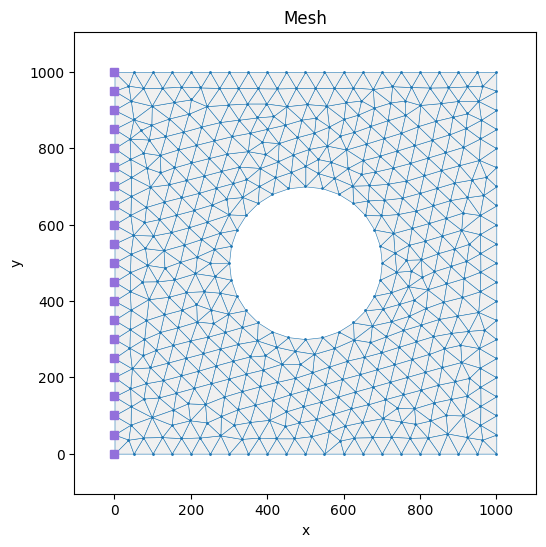

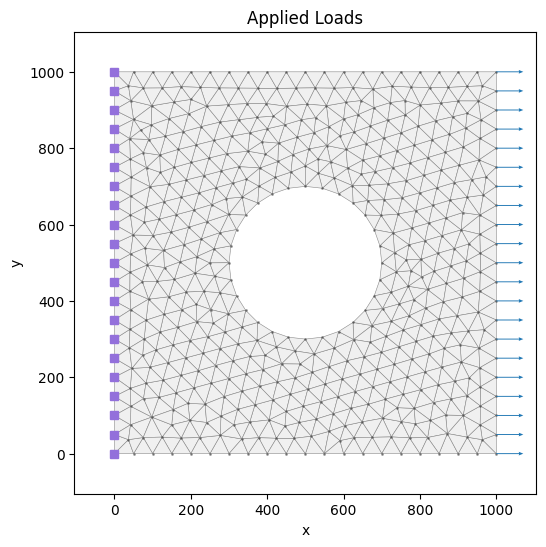

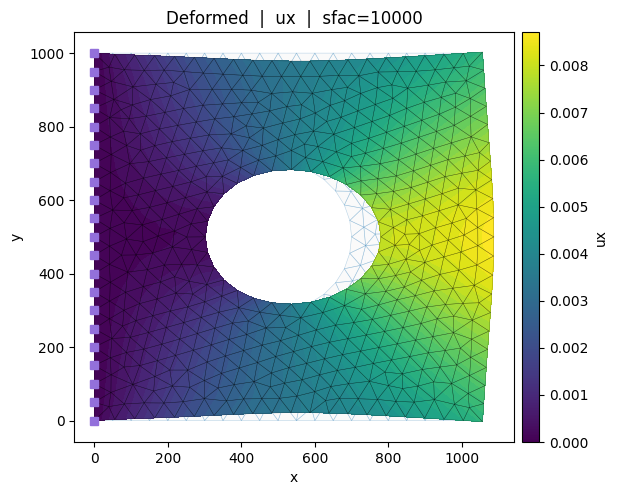

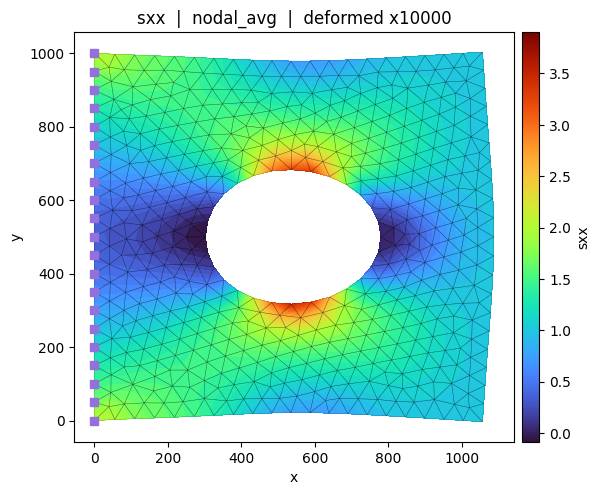

In [26]:
# Mesh
plot_mesh(
    nodes               = nodes,
    elements            = elements,
    show_node_labels    = False,
    show_element_labels = False,
    show_supports       = True,
    show_element_edges  = True,
    show_node_points    = True,
    figsize             = (6, 6),
    ax                  = None,
    save                = None,   
)


# Loads
plot_loads_2d(
    nodes    = nodes,
    elements = elements,
    F_load   = F_load,
    show_element_edges  = True,
    show_node_points    = True,
    show_supports       = True,
    figsize  = (6, 6),
    ax       = None,
    save     = None,    
)

# Deformed
plot_deformed(
    nodes     = nodes,
    elements  = elements,
    u         = u,
    component = 'ux',   # 'ux', 'uy', 'umag'
    sfac      = 10000,
    cmap      = 'viridis',
    limit               = None,      
    show_element_edges  = True,
    show_node_points    = False,
    show_supports       = True,
    figsize             = (6, 6),
    ax                  = None,
    save                = None,
)

# Stress or Strain Field
plot_field_2d(
    nodes       = nodes,
    elements    = elements,
    u           = u,
    component   = 'sxx',       # 'sxx','syy','sxy','vmis','s1','s2','exx','eyy','exy','e1','e2'
    result_type = 'nodal_avg',  # 'nodal_avg' or 'element'
    deformed    = True,
    sfac        = 10000,
    limit       = None,         # e.g. (-250, 250) highlights elements outside range in red
    # levels      = 20,
    cmap        = 'turbo',
    show_element_edges  = True,
    show_node_points    = False,
    show_supports       = True,
    figsize             = (6, 6),
    ax                  = None,
    save                = None,
)

In [27]:
# import openseespy.opensees as ops
import opensees as ops
import opsvis as opsv

ops.wipe()
ops.model('basicBuilder','-ndm',2,'-ndf',2)



         OpenSees -- Open System For Earthquake Engineering Simulation
                 Pacific Earthquake Engineering Research Center
                        Version 3.7.2 64-Bit


      (c) Copyright 1999-2016 The Regents of the University of California
                              All Rights Reserved
  (Copyright and Disclaimer @ http://www.berkeley.edu/OpenSees/copyright.html)


  *********** (o_O) OPENSEES (>'-')> Ladruño4ever *********** 3.7.2




In [28]:
# Nodes
for tag, (x, y, z) in mesh['nodes'].items():
    ops.node(tag, x, y)

In [29]:
# Boundary conditions
fixed_nodes = set()
for phys_id, condition in restrain_dictionary.items():
    if phys_id not in mesh['elements']:
        continue
    for connectivity in mesh['elements'][phys_id]['connectivity']:
        for tag in connectivity:
            fixed_nodes.add(tag)

for tag in fixed_nodes:
    rx = 1 if restrain_dictionary[101][0] == 'r' else 0
    ry = 1 if restrain_dictionary[101][1] == 'r' else 0
    ops.fix(tag, rx, ry)

In [30]:
# Material
solidMaterialTag = 1

nuYX = Steel.nu
nuZX = Steel.nu
nuZY = Steel.nu

Ex   = Steel.E
Ey   = Steel.E
Ez   = Steel.E

Gxy  = Ex / (2 * (1 + nuYX))
Gxz  = Ey / (2 * (1 + nuZX))
Gyz  = Ez / (2 * (1 + nuZY))

rho  = Steel.rho

ops.nDMaterial('ElasticOrthotropic', solidMaterialTag,
               Ex, Ey, Ez,
               nuYX, nuZX, nuZY,
               Gxy, Gxz, Gyz,
               rho)

In [31]:
# Elements
for elem_tag, connectivity in zip(mesh['elements'][201]['element_tags'],
                                  mesh['elements'][201]['connectivity']):
    
    ops.element('tri31', elem_tag, *connectivity,
                SteelPlate.thickness, 'PlaneStress', solidMaterialTag)

Tri31 - Written by Roozbeh G. Mikola and N.Sitar, UC Berkeley


<Axes: >

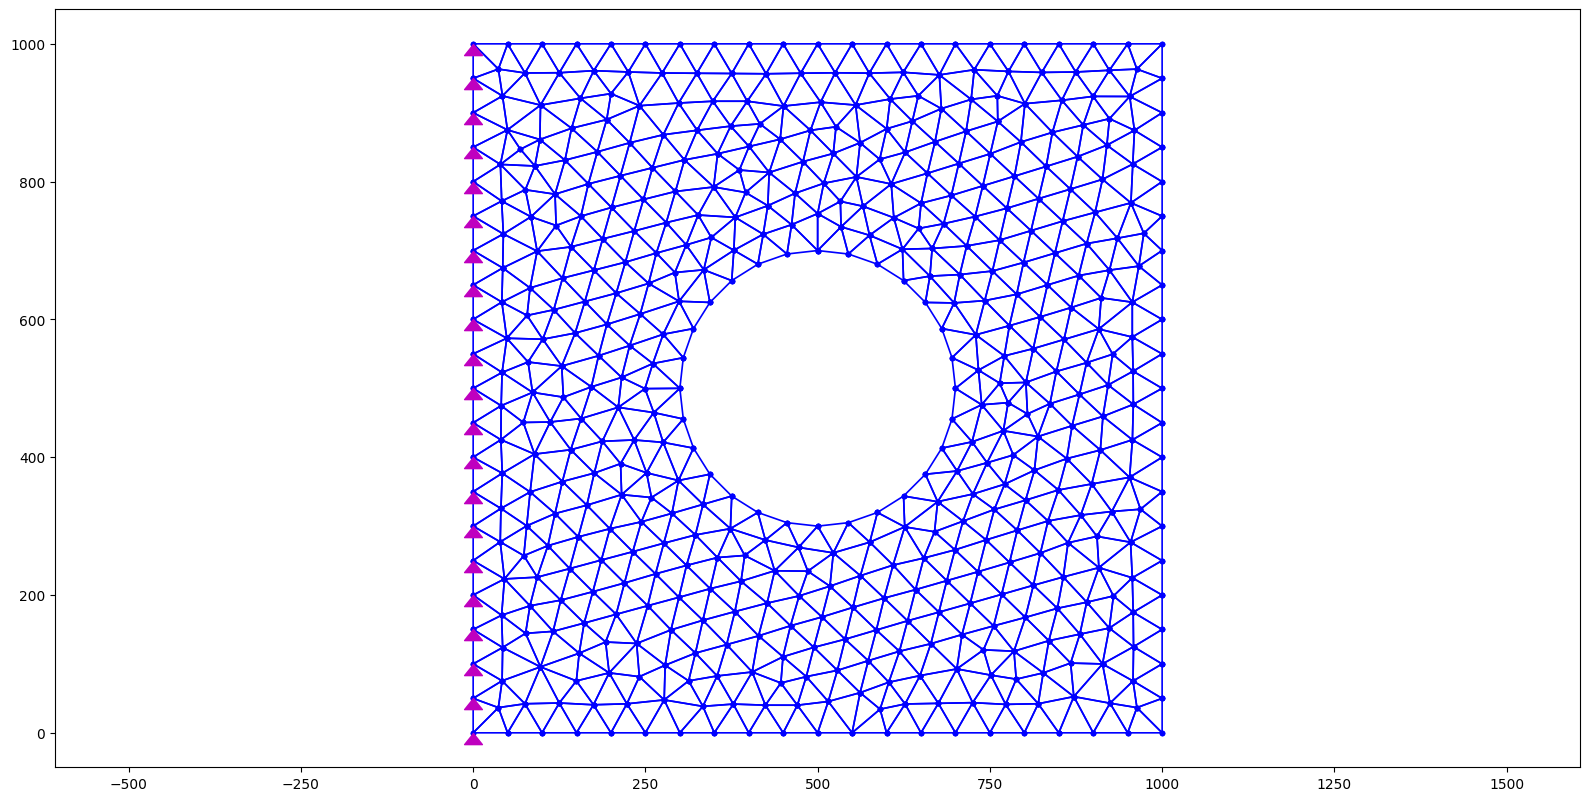

In [32]:
opsv.plot_model(node_labels=0, element_labels=0, fig_wi_he=(50,25))

In [34]:

# Loads
ts_tag      = 2
pattern_tag = 2
ops.timeSeries('Linear', ts_tag)
ops.pattern('Plain', pattern_tag, ts_tag)
for node in nodes:
    fx = F_load[node.idx[0]]
    fy = F_load[node.idx[1]]
    if abs(fx) > 0 or abs(fy) > 0:
        ops.load(int(node.name), float(fx), float(fy))


In [35]:
NstepGravity=10
DGravity=1/NstepGravity

ops.system("FullGeneral")
ops.numberer("Plain")
ops.constraints("Plain")
ops.integrator("LoadControl", DGravity )
ops.test("NormUnbalance", 1.0e-6, 100 , 0)
ops.algorithm("Newton")
ops.analysis("Static")

ops.analyze(NstepGravity)

0

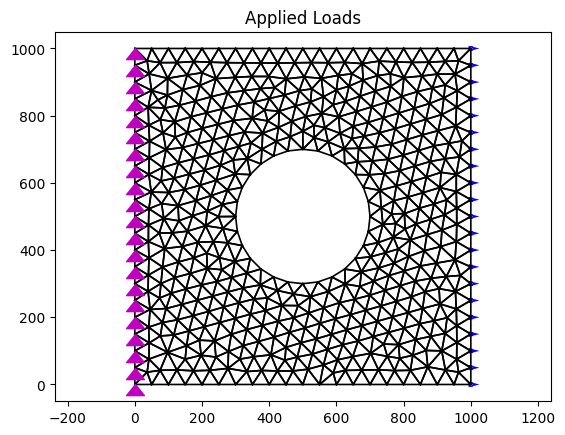

In [36]:
opsv.plot_loads_2d(sfac=0.1)
for txt in plt.gca().texts:
    txt.set_visible(False)
plt.title('Applied Loads')
plt.show()

10

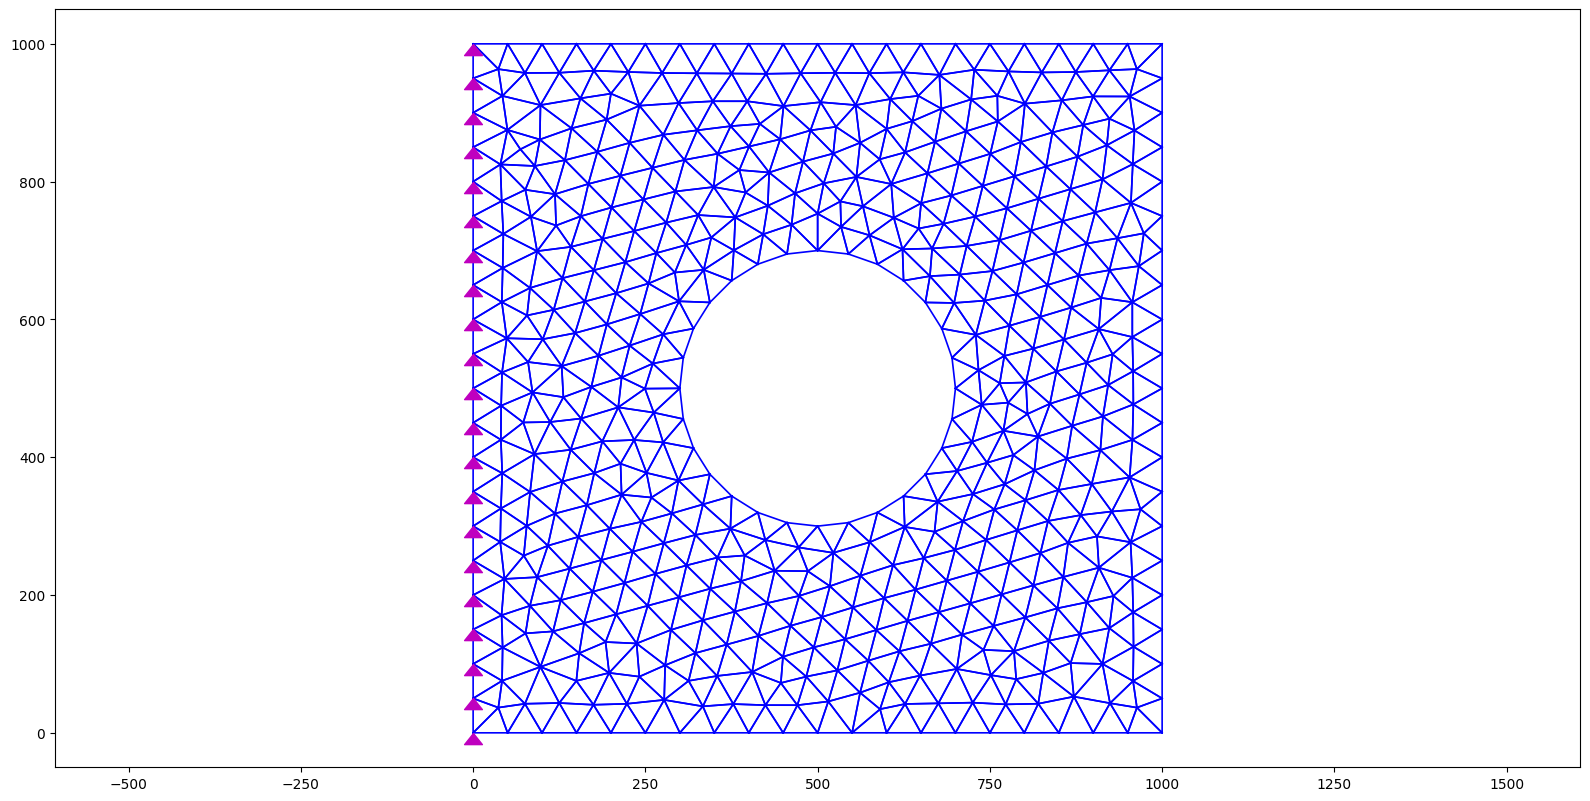

In [37]:
opsv.plot_defo(
    sfac=10,
    fig_wi_he=(50, 25),
    endDispFlag=True,
    unDefoFlag=0
)

Text(0.5, 1.0, 'sxx')

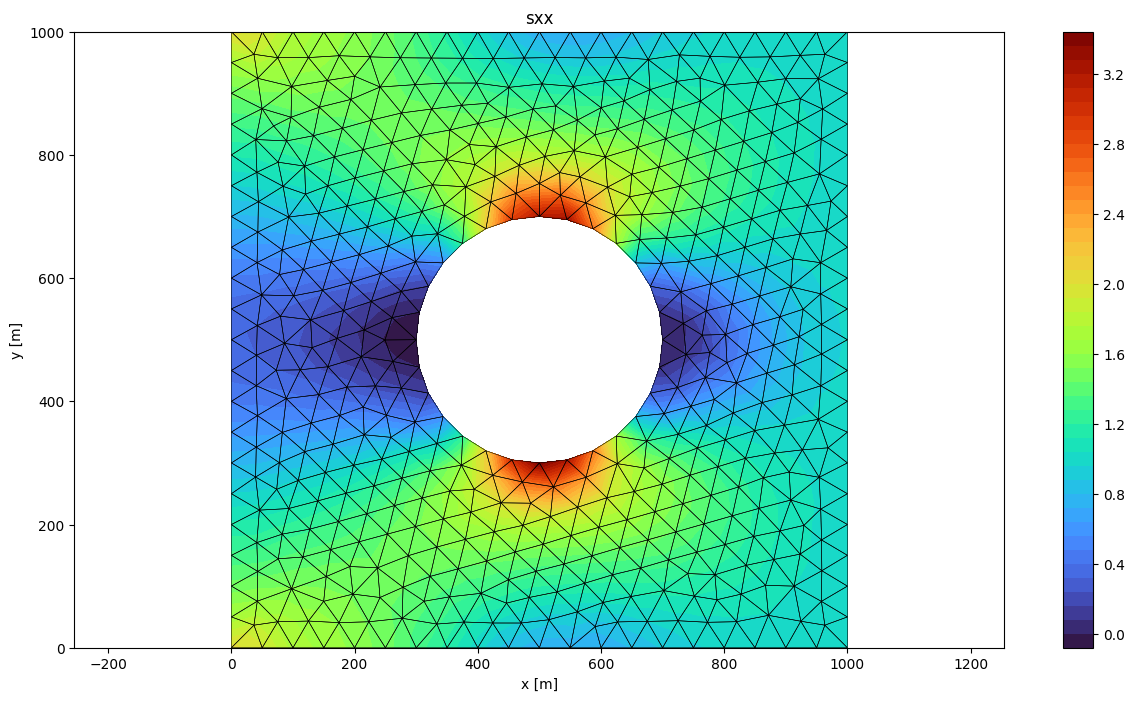

In [38]:
jstr = 'sxx'
# jstr = 'syy'
# jstr = 'sxy'
# jstr = 'vmis'
# jstr = 's1'
# jstr = 's2'
# jstr = 'angle'

plt.figure(figsize=(15, 8))
opsv.plot_stress(jstr)
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title(f'{jstr}')